In [ ]:
from random_date_generator import random_date_generator
from hll import HyperLogLog
import matplotlib.pyplot as plt
import unittest

**Юнит тесты**

In [9]:
unittest.main(module='test_hll', argv=[''], exit=False)

small: True=14798, Estimate=14796, Abs Error=2, Error%=0.01
norm: True=28482, Estimate=28472, Abs Error=10, Error%=0.04


.

big: True=28490, Estimate=28480, Abs Error=10, Error%=0.04


.
----------------------------------------------------------------------
Ran 2 tests in 4.824s

OK



Small error=0.01, Norm error=0.04
Merged: True=28487, Estimate=28477, Abs Error=10, Error%=0.04


**Оценка зависимости погрешности от параметров алгоритма**

In [7]:
def run_experiment(sizes, p_values):
    errors_pct = {}
    for p in p_values:
        for label, size in sizes.items():
            stream = [next(random_date_generator()) for _ in range(size)]
            hll = HyperLogLog(p=p)
            for item in stream:
                hll.add(item)
            true_count = len(set(stream))
            estimate = hll.count()
            error_pct = abs(estimate - true_count) / true_count * 100
            errors_pct.setdefault(label, []).append(error_pct)
    return errors_pct
    
def test_dependency():
    sizes = {'small': 21000, 'norm': 241000, 'big': 1000111}
    p_vals = [10, 12, 14, 16]
    errors = run_experiment(sizes, p_vals)

    for label, errs in errors.items():
        plt.plot(p_vals, errs, label=label)
    plt.xlabel('p parameter')
    plt.ylabel('Error percentage')
    plt.legend()
    plt.show()

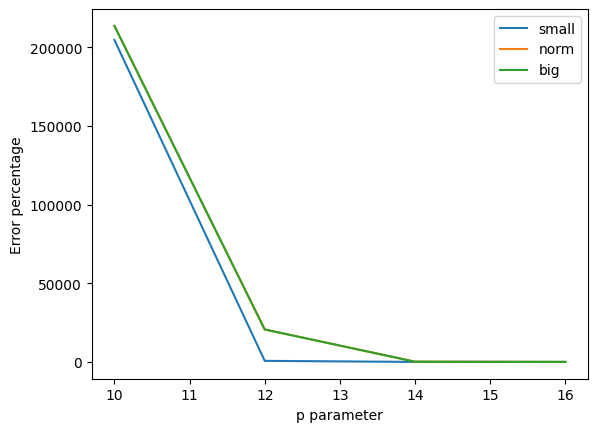

In [8]:
test_dependency()